## Initialisation

In [74]:
import time
import importlib
from ugot import ugot
import pose_yolo
import cv2
import numpy as np

# Reload pose_yolo so any edits to pose_yolo.py are picked up before importing
importlib.reload(pose_yolo)
from pose_yolo import run_pose_control_inline

from IPython.display import clear_output
from IPython.display import display, clear_output, Image


# ── Configuration ─────────────────────────────────────────────────────────────
ROBOT_IP    = "192.168.88.1"  # Single source-of-truth IP for all robot calls
TEXT_NAME   = "LEFT"          # Text sign to detect at the Y-intersection
TARGET_NAME = "Ryan"         # Face to locate for drop-off

# Timeouts in seconds (set to None to disable)
COLOR_TIMEOUT    = 60
APRILTAG_TIMEOUT = 60
TEXT_TIMEOUT     = 30
FACE_TIMEOUT     = 60

# ── Robot setup ───────────────────────────────────────────────────────────────
got = ugot.UGOT()
got.initialize(ROBOT_IP)

got.load_models([
    "color_recognition",  # detects dominant colours
    "word_recognition",   # OCR: reads printed text
    "line_recognition",   # for line-following tasks
    "face_recognition",   # identifies registered faces by name
    "apriltag_qrcode",    # AprilTag detection
])

got.set_track_recognition_line(0)  # 0 = single-line mode
got.open_camera()

print("INITIALISATION COMPLETED!")

192.168.88.1:50051
INITIALISATION COMPLETED!


## Helper Functions

### `AP_centralization_approaching`

| Parameter | Default | Description |
|---|---|---|
| `distance` | 0.15 m | Stop when the tag is within this many metres |
| `gap` | 20 px | Pixel tolerance around centre before triggering a strafe correction |
| `fwd_spd` | 10 | Forward drive speed (cm/s) |
| `strafe_spd` | 10 | Left/right correction speed (cm/s) |

### `face_find_and_approach`

| Parameter | Default | Description |
|---|---|---|
| `target_name` | `TARGET_NAME` | Registered face name to search for |
| `gap` | 15 px | Pixel tolerance around centre (x = 320 ± gap) before strafing |
| `turn_spd` | 10 | Rotation speed while scanning for the target (cm/s) |
| `strafe_spd` | 10 | Sideways correction speed during approach (cm/s) |
| `fwd_spd` | 10 | Forward approach speed (cm/s) |
| `height` | 120 px | Face bounding-box height at which the robot stops (distance proxy) |
| `adjust_turn` | 10 | Fine-rotation speed for centering on the face |
| `timeout` | `FACE_TIMEOUT` | Max seconds to search before giving up (`None` = no limit) |

In [ ]:
def face_text_preview(img_handle):
    """Update the live camera display with face + text overlays."""
    frame = got.read_camera_data()

    if frame is None:  # ← guard: skip frame if camera not ready
        return

    nparr = np.frombuffer(frame, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

    if img is None:    # ← guard: skip if decode failed
        return

    name = got.get_words_result()
    if name:
        cv2.putText(img, f"text: {name}", (20, 40), 0, 0.8, (0, 255, 0), 2)

    faces = got.get_face_recognition_total_info()
    if faces:
        cv2.putText(img, f"face: {faces[0]}", (20, 70), 0, 0.8, (0, 255, 0), 2)

    _, jpeg = cv2.imencode(".jpg", img)
    img_handle.update(Image(data=jpeg.tobytes()))

In [ ]:
def AP_centralization_approaching_safe(distance=0.15, gap=20, fwd_spd=10, strafe_spd=10):
    last_AP_info = None
    consecutive_misses = 0
    MAX_MISSES = 16  # If tag disappears for 8 frames in a row, assume we're close enough

    while True:
        AP_info = got.get_apriltag_total_info()

        if not AP_info:
            consecutive_misses += 1
            got.mecanum_stop()

            # Tag has been gone long enough — we're probably too close to see it
            if consecutive_misses >= MAX_MISSES and last_AP_info is not None:
                print(f"Tag out of frame for {MAX_MISSES} frames — assuming close enough.")
                return last_AP_info  # Use last known good data

            time.sleep(0.1)
            continue

        # Tag visible — reset miss counter
        consecutive_misses = 0
        last_AP_info = AP_info
        got.mecanum_stop()
        AP_x        = AP_info[0][1]
        AP_distance = AP_info[0][6]

        if AP_x < 320 - gap:
            got.mecanum_move_xyz(-strafe_spd, fwd_spd, 0)
        elif AP_x > 320 + gap:
            got.mecanum_move_xyz(strafe_spd, fwd_spd, 0)
        elif AP_distance > distance:
            got.mecanum_move_xyz(0, fwd_spd, 0)
        else:
            got.mecanum_stop()
            print(f"AprilTag reached — x: {AP_x}, distance: {AP_distance:.3f}m")
            return last_AP_info


def pick_up(AP_info):           # ← takes AP_info as parameter
    AP_x        = AP_info[0][1] # ← uses passed-in data, no re-read
    AP_distance = AP_info[0][6]

    got.mechanical_joint_control(0, 30, 30, 1000)
    got.mechanical_clamp_release()
    time.sleep(2)

    joint1 = int((AP_x - 320) * -1 / 10)
    joint3 = int(AP_distance * 100 - 85)

    print(f"Joint1: {joint1}°, Joint3: {joint3}°")
    got.mechanical_joint_control(joint1, 0, joint3, 500)
    time.sleep(1)

    got.mechanical_clamp_close()
    time.sleep(2)
    got.mechanical_joint_control(0, 30, 30, 1000)

def line_follow(mult=0.25, speed=35):
    """Follow the detected line by turning proportionally to the line offset."""
    offset, line_type, x, y = got.get_single_track_total_info()
    rotation_speed = int(offset * mult)
    got.mecanum_move_xyz(x_speed=0, y_speed=speed, z_speed=rotation_speed)
    return line_type, x, y
def detect_line(frame):
    # TODO: replace with real line detection
    return 0, 0, 0
got.open_camera()

def face_find_and_approach(
    gap=10, target_name="Stranger", turn_spd=10, strafe_spd=10, fwd_spd=10, height=80, adjust_turn=10
):
    face_name = None
    img_handle = display(None, display_id=True)  # single display slot, updates in-place

    try:
        # Phase 1: Spin and search
        while True:
            got.mecanum_move_xyz(0, 0, turn_spd)  # FIX: was got.mecanum_turn_speed(...)
            face_text_preview(img_handle) 
            time.sleep(0.3)         # FIX: update preview every frame

            name = got.get_words_result()
            faces = got.get_face_recognition_total_info()
            if faces:
                face_name = faces[0][0]

            if name == target_name or face_name == target_name:
                got.mecanum_stop()
                print(f"Saw {target_name}!")
                got.mecanum_turn_speed_times(turn=3, speed=20, times=adjust_turn, unit=2)
                break

        # Phase 2: Approach
        while True:
            face_text_preview(img_handle)          # FIX: update preview every frame

            name = got.get_words_result()
            faces = got.get_face_recognition_total_info()

            if not faces:
                got.mecanum_move_xyz(0, fwd_spd, 0)  # FIX: was got.mecanum_translate_speed(...)
            else:
                c_x = faces[0][1]
                h   = faces[0][3]
                if h < height:
                    if c_x < 320 - gap:
                        got.mecanum_move_xyz(x_speed=-strafe_spd, y_speed=fwd_spd, z_speed=0)
                    elif c_x > 320 + gap:
                        got.mecanum_move_xyz(x_speed=strafe_spd, y_speed=fwd_spd, z_speed=0)
                    else:
                        got.mecanum_move_xyz(x_speed=0, y_speed=fwd_spd, z_speed=0)
                else:
                    got.mecanum_stop()
                    print(f"Reached {target_name}!")
                    return  # FIX: return instead of break so caller knows we're done

        got.mecanum_stop()

    except KeyboardInterrupt:
        print("Done")
        got.mecanum_stop()

## Main Mission Sequence

In [73]:
red_seen = False
got.set_track_recognition_line(line_type=0)

try:
    # ── Phase 1: Wait for Red then Green ─────────────────────────────────────
    while True:
        color = got.get_color_total_info()[0]

        if not red_seen:
            if color == "Red":
                got.screen_display_background(3)
                print("Red detected!")
                red_seen = True
        else:
            if color == "Green":
                got.screen_display_background(6)
                print("Green detected!")
                time.sleep(1)
                break

    # ── Phase 2: Search for AprilTag ─────────────────────────────────────────
    print("Searching for AprilTag...")
    got.mecanum_stop()
    time.sleep(0.3)

    search_start = time.time()
    search_timeout = 15

    while True:
        if time.time() - search_start > search_timeout:
            print("AprilTag not found within timeout!")
            got.mecanum_stop()
            break

        AP_info = got.get_apriltag_total_info()

        if AP_info:
            print(f"AprilTag found! Distance: {AP_info[0][6]:.2f}m, X: {AP_info[0][1]}")
            got.mecanum_stop()
            time.sleep(0.3)

            # ── Phase 3: Approach and pick up ────────────────────────────────
            ap_info = AP_centralization_approaching_safe(distance=0.17, gap=20, fwd_spd=10, strafe_spd=10)
            pick_up(ap_info)
            print("Picked up!")
            time.sleep(1) 
            break
        else:
            got.mecanum_move_xyz(0, 8, 0)
            time.sleep(0.2)
            got.mecanum_stop()
            time.sleep(0.15)

    print("Finished!")

except KeyboardInterrupt:
    got.mecanum_stop()
    print("Done!")

Red detected!
Green detected!
Searching for AprilTag...
AprilTag found! Distance: 0.60m, X: 333.88
AprilTag reached — x: 314.45, distance: 0.160m
Joint1: 0°, Joint3: -69°
Picked up!
Finished!


In [ ]:
AP_info = got.get_apriltag_total_info()
print("AP_info:", AP_info)

if AP_info:
    print("AP_x:", AP_info[0][1])
    print("AP_distance:", AP_info[0][6])
else:
    print("Empty — tag not visible")

In [ ]:
    # Line follow pt 1

print("Starting line following...")
while True:
    line_type, _, _ = line_follow(mult=0.25, speed=20)

    if line_type == 0:  # 0 = no line detected,
        print("No line!")
        break

    if line_type == 2:  # 2 = y-intersection detected
        print("Y-intersection!")
        break

got.mecanum_stop()

# If you want to go forward a bit to move closer to the text:
got.mecanum_move_speed_times(direction=0, speed=20, times=5, unit=1)


# Text Recognition
print("Starting text recognition...")
while True:
    text = got.get_words_result()
    time.sleep(1)
    print("Text:", text)
    # React to specific command words
    if text == "LEFT":
        # Turn counter-clockwise by ~45 degrees
        got.mecanum_turn_speed_times(turn=2, speed=20, times=45, unit=2)
        break
    elif text == "RIGHT":
        # Turn clockwise by ~45 degrees
        got.mecanum_turn_speed_times(turn=3, speed=20, times=45, unit=2)
        break
    clear_output

# Line follow pt 2
print("Starting line follow...")

print("Starting line follow...")
while True:
    line_type, _, _ = line_follow(mult=0.25, speed=40)
    if line_type in [0]:
        got.mecanum_stop()
        break



In [ ]:
print("Starting line follow...")
while True:
    line_type, _, _ = line_follow(mult=0.25, speed=40)
    if line_type in [0]:
        got.mecanum_stop()
        break

print("Starting line follow...")

# Brief pause to get past the merge point before checking line type
got.mecanum_move_speed_times(direction=0, speed=20, times=20, unit=1)

while True:
    line_type, _, _ = line_follow(mult=0.25, speed=40)
    if line_type == 0:  # Stop ONLY on no-line, ignore intersections
        got.mecanum_stop()
        break


In [ ]:
got.mecanum_stop()

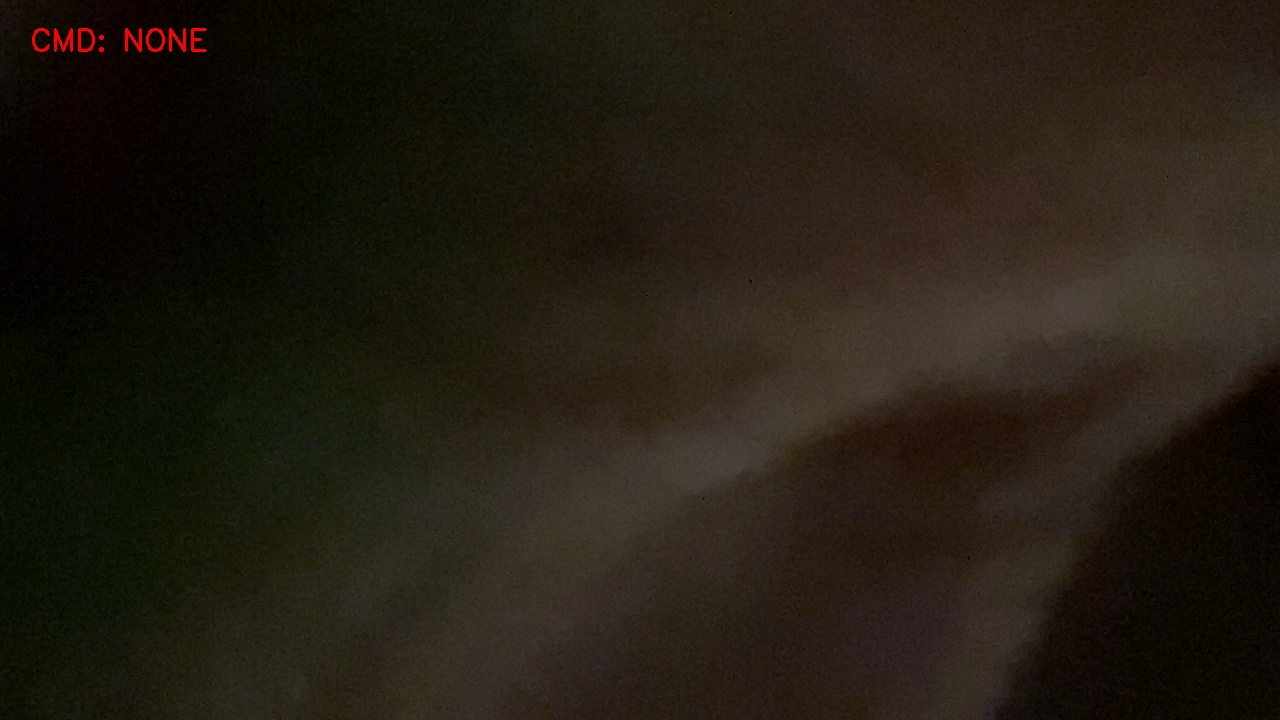

KeyboardInterrupt: 

In [81]:
print("Starting Pose Control...")
run_pose_control_inline(
    robot_ip=ROBOT_IP,
    forward_speed=30,
    backward_speed=30,
    turn_speed=45,
    camera_index=1,
    model_path="yolov8n-pose.pt",
    up_margin_factor=0.6,
    down_margin_factor=0.6,
    min_conf=0.3,
    enable_robot=True,
    debounce_frames=2,
    max_frames=None,
    got=got,
)
got.open_camera()

try:
    print(f"Searching for face: {TARGET_NAME}")

    # FIX: no while True — run once, then drop off
    face_find_and_approach(target_name=TARGET_NAME)

    # Drop off
    time.sleep(1)
    got.mechanical_joint_control(angle1=0, angle2=0, angle3=-30, duration=500)
    got.mechanical_clamp_release()
    print("AprilTag dropped!")

except KeyboardInterrupt:
    print("Done")
    got.mecanum_stop()
    clear_output(wait=True)
